<a href="https://colab.research.google.com/github/LeonardooAlves/WM9B7-AIDL/blob/main/Week%201/2_ANN_Forward_Propagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Artificial Neural Networks — Forward Propagation

**MSc Applied Artificial Intelligence — AI and Deep Learning Module**  
**WMG, University of Warwick — 2025/26**

---

## Table of Contents

1. [Setup](#1.-Setup)
2. [Recap — The XOR Problem](#2.-Recap-—-The-XOR-Problem)  
3. [Solving XOR: Combining Perceptrons into a Network](#3.-Solving-XOR:-Combining-Perceptrons-into-a-Network)  
   3.1 The Key Insight: Decompose XOR · 3.2 Building XOR from AND, OR, and NAND · 3.3 From Logic to Neurons  
4. [Gradient Descent and Differentiable Activations](#4.-Gradient-Descent-and-Differentiable-Activations)  
   4.1 Activation Functions · 4.2 Binary Cross-Entropy Loss · 4.3 The Gradient Descent Update Rule  
5. [From Perceptron to Multi-Layer Perceptron](#5.-From-Perceptron-to-Multi-Layer-Perceptron)  
   5.1 Forward Propagation · 5.2 Parameter Count  
6. [Forward Propagation — Detailed Walkthrough](#6.-Forward-Propagation-—-Detailed-Walkthrough)  
   6.1 Known Weights · 6.2 Step-by-Step for $\mathbf{x} = [1, 0]$ · 6.3 All XOR Inputs · 6.4 The Hidden Layer's Transformation  
7. [Training the XOR Network with Gradient Descent](#7.-Training-the-XOR-Network-with-Gradient-Descent)  
   7.1 The NeuralNetwork Class · 7.2 Training · 7.3 Predictions and Decision Boundary  
8. [Evaluation Metrics](#8.-Evaluation-Metrics)  
   8.1 Confusion Matrix · 8.2 Precision, Recall, F1 · 8.3 Evaluating the XOR Network  
9. [Evaluation on a Larger Dataset](#9.-Evaluation-on-a-Larger-Dataset)  
10. [PyTorch Implementation](#10.-PyTorch-Implementation)  
    10.1 XOR · 10.2 Moons  
11. [Comparison: NumPy vs PyTorch](#11.-Comparison:-NumPy-vs-PyTorch)  
12. [Exercises](#12.-Exercises)  
13. [Summary](#13.-Summary)

---

## Notebook Overview

This notebook accompanies the Introduction to Artificial Neural Networks session. It picks up directly where the **Introduction to the Perceptron** notebook left off — specifically from the XOR problem that the single perceptron could not solve.

| Section | Maps to Lecture Segment | Content |
|:---|:---|:---|
| §2–§3 | Segment 1 — The Perceptron | XOR recap, solving XOR by combining perceptrons |
| §4 | Segment 2 — Gradient Descent | Activation functions, loss functions, gradient updates |
| §5–§7 | Segment 3 — ANN Architecture | MLP forward propagation, training with backpropagation |
| §8–§9 | Segment 3 (continued) | Evaluation metrics, larger dataset evaluation |
| §10–§11 | Segment 3 (continued) | PyTorch implementation, NumPy vs PyTorch comparison |

**Prerequisites:** You should have completed the **Introduction to the Perceptron** notebook. In particular, you should be comfortable with the perceptron learning rule, the step function, decision boundaries, and the concept of linear separability. You should also understand why gradient descent requires a differentiable activation function (Section 8 of that notebook).

**Key question driving this notebook:** In the Perceptron notebook, we proved that a single perceptron *cannot* solve XOR. So how do we fix this? The answer — combining multiple perceptrons into layers — is the foundational idea behind all neural networks.

---
## 1. Setup

We import the same libraries as in the Perceptron notebook and define a consistent colour palette for our visualisations.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.facecolor': '#0F172A', 'figure.facecolor': '#0F172A',
    'text.color': '#E2E8F0', 'axes.labelcolor': '#E2E8F0',
    'xtick.color': '#94A3B8', 'ytick.color': '#94A3B8',
    'axes.edgecolor': '#334155', 'grid.color': '#334155', 'grid.alpha': 0.5,
})

COL = {
    'primary': '#6366F1', 'accent': '#06B6D4', 'green': '#10B981',
    'amber': '#F59E0B', 'red': '#EF4444', 'pink': '#EC4899',
    'text': '#E2E8F0', 'muted': '#94A3B8',
}

print('Setup complete.')

Setup complete.


---
## 2. Recap — The XOR Problem

In the Perceptron notebook, we established that a single perceptron computes:

$$z = \sum_{i=1}^{n} w_i x_i + b, \qquad \hat{y} = \text{step}(z) = \begin{cases} 1 & z \ge 0 \\ 0 & z < 0 \end{cases}$$

We successfully trained it on **AND** and **OR** gates (both linearly separable), but it **failed on XOR** — the decision boundary oscillated endlessly because no single straight line can separate the XOR classes.

Let's quickly confirm this limitation one more time, and also train the AND perceptron — we will need it shortly:

In [ ]:
# XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

def train_perceptron(X, y, alpha=0.1, epochs=100):
    np.random.seed(42)
    w = np.random.uniform(-0.5, 0.5, size=X.shape[1])
    b = 0.0
    for epoch in range(epochs):
        errors = 0
        for i in range(len(X)):
            z = np.dot(w, X[i]) + b
            y_pred = 1 if z >= 0 else 0
            e = y[i] - y_pred
            if e != 0:
                w += alpha * e * X[i]
                b += alpha * e
                errors += 1
        if errors == 0:
            return w, b, epoch + 1, True
    return w, b, epochs, False

w_and, b_and, ep_and, conv_and = train_perceptron(X_xor, np.array([0,0,0,1]))
w_xor, b_xor, ep_xor, conv_xor = train_perceptron(X_xor, y_xor)

print(f'AND gate: converged = {conv_and} in {ep_and} epochs')
print(f'XOR gate: converged = {conv_xor} after {ep_xor} epochs (max reached)')
print(f'\n\u2192 The perceptron CANNOT solve XOR. We need multiple layers.')

AND gate: converged = True in 5 epochs
XOR gate: converged = False after 100 epochs (max reached)

→ The perceptron CANNOT solve XOR. We need multiple layers.


**Output interpretation:** The AND perceptron converges in just a few epochs (it is linearly separable), but the XOR perceptron never converges — exactly as we observed in the previous notebook. The decision boundary plot shows that no matter where we place a single line, at least one XOR point ends up on the wrong side.

This is where we left off. The question now is: **can we overcome this limitation by using *more than one* perceptron?**

---
## 3. Solving XOR: Combining Perceptrons into a Network

This is the pivotal insight of neural networks. We already know that a single perceptron can learn AND, OR, and NAND (as shown in the Perceptron notebook exercises). What if we **combine** these simple gates to build something more complex?

### 3.1 The Key Insight: Decompose XOR

Recall the XOR truth table side by side with some gates we already know how to learn:

| $x_1$ | $x_2$ | AND | OR | NAND | **XOR** |
|:-----:|:-----:|:---:|:--:|:----:|:-------:|
| 0     | 0     | 0   | 0  | 1    | **0**   |
| 0     | 1     | 0   | 1  | 1    | **1**   |
| 1     | 0     | 0   | 1  | 1    | **1**   |
| 1     | 1     | 1   | 1  | 0    | **0**   |

Look carefully at the XOR column and try to express it using the other gates. There is a well-known identity from Boolean logic:

$$\text{XOR}(x_1, x_2) = \text{AND}\bigl(\text{OR}(x_1, x_2),\; \text{NAND}(x_1, x_2)\bigr)$$

In other words: **XOR is true when at least one input is on (OR) AND it is not the case that both are on (NAND).**

### 3.2 Building XOR from AND, OR, and NAND

Let's verify this decomposition row by row:

| $x_1$ | $x_2$ | $h_1 = \text{OR}(x_1, x_2)$ | $h_2 = \text{NAND}(x_1, x_2)$ | $\hat{y} = \text{AND}(h_1, h_2)$ | XOR |
|:-----:|:-----:|:---:|:----:|:---:|:---:|
| 0 | 0 | 0 | 1 | AND(0, 1) = **0** | 0 ✓ |
| 0 | 1 | 1 | 1 | AND(1, 1) = **1** | 1 ✓ |
| 1 | 0 | 1 | 1 | AND(1, 1) = **1** | 1 ✓ |
| 1 | 1 | 1 | 0 | AND(1, 0) = **0** | 0 ✓ |


**Logic Definitions:**
* Hidden Layer 1 ($h_1$): $\text{OR}(x_1, x_2)$
* Hidden Layer 2 ($h_2$): $\text{NAND}(x_1, x_2)$
* Output ($\hat{y}$): $\text{AND}(h_1, h_2)$

It works perfectly. Each individual gate (OR, NAND, AND) is linearly separable and can be learned by a single perceptron. By combining them, we solve a problem that no single perceptron could.

### 3.3 From Logic Gates to a Neural Network

This decomposition maps directly onto a **two-layer neural network**:

```
        ┌─────────────────────────┐
Input   │     Hidden Layer        │    Output Layer
        │                         │
x₁ ────►│  h₁ = OR(x₁, x₂)     ─┤───►
        │                         │     ŷ = AND(h₁, h₂)
x₂ ────►│  h₂ = NAND(x₁, x₂)  ─┤───►
        │                         │
        └─────────────────────────┘
         2 perceptrons (hidden)       1 perceptron (output)
```

- **Hidden layer:** Two perceptrons operating in parallel. $h_1$ computes OR and $h_2$ computes NAND. Each receives the *same* inputs $(x_1, x_2)$ but with *different* weights and biases.
- **Output layer:** One perceptron that takes the hidden layer outputs $(h_1, h_2)$ as inputs and computes AND.

This is a **multi-layer perceptron (MLP)** with architecture **[2, 2, 1]**: 2 inputs → 2 hidden neurons → 1 output neuron. The "hidden" neurons are called that because they are internal to the network — the user only sees the final output.

**The fundamental insight:** Each hidden neuron draws its own decision boundary in the input space. The output neuron then **combines** these boundaries to create a more complex, non-linear separation. This is how neural networks gain their expressive power.

In [ ]:
# ============================================================
# Verifying the XOR decomposition with individual perceptrons
# ============================================================

# Train individual perceptrons for OR and NAND
w_or, b_or, ep_or, conv_or = train_perceptron(X_xor, np.array([0, 1, 1, 1]))    # OR labels
w_nand, b_nand, ep_nand, conv_nand = train_perceptron(X_xor, np.array([1, 1, 1, 0]))  # NAND labels

print("=== Individual Perceptrons (from Perceptron Notebook) ===\n")
print(f"OR perceptron:   w = [{w_or[0]:+.2f}, {w_or[1]:+.2f}], b = {b_or:+.2f}  (converged in {ep_or} epochs)")
print(f"NAND perceptron: w = [{w_nand[0]:+.2f}, {w_nand[1]:+.2f}], b = {b_nand:+.2f}  (converged in {ep_nand} epochs)")
print(f"AND perceptron:  w = [{w_and[0]:+.2f}, {w_and[1]:+.2f}], b = {b_and:+.2f}  (converged in {ep_and} epochs)")

print("\n=== Composing XOR = AND(OR, NAND) ===\n")
print(f'{"x1":>3s} {"x2":>3s} | {"h1=OR":>7s} {"h2=NAND":>8s} | {"AND(h1,h2)":>11s} | {"XOR true":>9s}  {"✓/✗":>3s}')
print('-' * 58)

all_correct = True
for i in range(4):
    # Hidden layer: compute OR and NAND using trained perceptrons
    z_or = np.dot(w_or, X_xor[i]) + b_or
    h1 = 1 if z_or >= 0 else 0  # OR output

    z_nand = np.dot(w_nand, X_xor[i]) + b_nand
    h2 = 1 if z_nand >= 0 else 0  # NAND output

    # Output layer: AND of the hidden outputs
    z_out = np.dot(w_and, np.array([h1, h2])) + b_and
    y_hat = 1 if z_out >= 0 else 0

    correct = '✓' if y_hat == y_xor[i] else '✗'
    if y_hat != y_xor[i]: all_correct = False
    print(f'{X_xor[i,0]:3.0f} {X_xor[i,1]:3.0f} |   {h1:5d}    {h2:5d} |     {y_hat:5d}   |     {y_xor[i]:5d}  {correct:>3s}')

print(f'\nAll correct: {all_correct}')
print("\n→ Three perceptrons (each linearly separable) combine to solve XOR!")

=== Individual Perceptrons (from Perceptron Notebook) ===

OR perceptron:   w = [+0.17, +0.45], b = -0.10  (converged in 5 epochs)
NAND perceptron: w = [-0.23, -0.15], b = +0.30  (converged in 12 epochs)
AND perceptron:  w = [+0.07, +0.25], b = -0.30  (converged in 5 epochs)

=== Composing XOR = AND(OR, NAND) ===

 x1  x2 |   h1=OR  h2=NAND |  AND(h1,h2) |  XOR true  ✓/✗
----------------------------------------------------------
  0   0 |       0        1 |         0   |         0    ✓
  0   1 |       1        1 |         1   |         1    ✓
  1   0 |       1        1 |         1   |         1    ✓
  1   1 |       1        0 |         0   |         0    ✓

All correct: True

→ Three perceptrons (each linearly separable) combine to solve XOR!


**Output interpretation:** Each row traces the signal through our hand-built network. First, the two hidden perceptrons (OR and NAND) independently classify the input. Then the output perceptron (AND) combines their results. The final column confirms that this combination perfectly matches the XOR truth table.

This is a profound result: **no single perceptron can solve XOR, but three perceptrons working together can.** The key is that the hidden layer transforms the input into a new representation where the problem *becomes* linearly separable — the AND perceptron at the output then trivially separates the two classes in this new space.

> **Looking ahead:** In practice, we do not hand-pick which gate each hidden neuron should learn. Instead, we initialise the weights randomly and use **gradient descent + backpropagation** to let the network *discover* a useful decomposition on its own. For this, we need differentiable activation functions — which brings us to the next section.

---
## 4. Gradient Descent and Differentiable Activations

In Section 3 we showed that combining perceptrons can solve XOR, but we hand-picked the weights. To *learn* the weights automatically in a multi-layer network, we need two things that the step function cannot provide:

1. **A differentiable activation function** — so we can compute gradients through every layer.
2. **A loss function** — a smooth, continuous measure of how wrong the predictions are.

In the Perceptron notebook (Section 8), we introduced the sigmoid function and binary cross-entropy for a single neuron. Here we extend those ideas to multiple layers.

### 4.1 Activation Functions

Different activation functions suit different parts of a network:

| Function | Formula | Range | Derivative | Typical Use |
|:---|:---|:---|:---|:---|
| **Sigmoid** | $\sigma(z) = \frac{1}{1+e^{-z}}$ | $(0,1)$ | $\sigma(1-\sigma)$ | Output layer (binary classification) |
| **Tanh** | $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $(-1,1)$ | $1-\tanh^2(z)$ | Hidden layers (zero-centred) |
| **ReLU** | $\max(0,z)$ | $[0,\infty)$ | $\mathbb{1}_{z>0}$ | Hidden layers (modern default) |

**Why not use the step function?** As discussed in the Perceptron notebook, the step function has zero gradient almost everywhere. During backpropagation, gradient information must flow backwards through *every* layer. If any layer uses a non-differentiable function, the gradient signal is destroyed and no layer before it can learn. Smooth activations like sigmoid, tanh, and ReLU keep the gradient flowing.

### 4.2 Binary Cross-Entropy Loss

For binary classification, we use the same loss function as in the Perceptron notebook, now applied to the output of a multi-layer network:

$$L = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log \hat{y}^{(i)} + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) \right]$$

where $m$ is the number of training samples and $\hat{y}^{(i)}$ is the network's output probability for sample $i$.

### 4.3 The Gradient Descent Update Rule

Recall from the Perceptron notebook that the gradient $\nabla L$ points in the direction of steepest *ascent* of the loss. To *decrease* the loss, we step in the opposite direction:

$$\mathbf{W}^{[l]} \leftarrow \mathbf{W}^{[l]} - \alpha \frac{\partial L}{\partial \mathbf{W}^{[l]}}$$

The challenge in a multi-layer network is computing $\frac{\partial L}{\partial \mathbf{W}^{[l]}}$ for *every* layer — this is what **backpropagation** does, using the chain rule to propagate the gradient backwards from the output to the input, layer by layer.

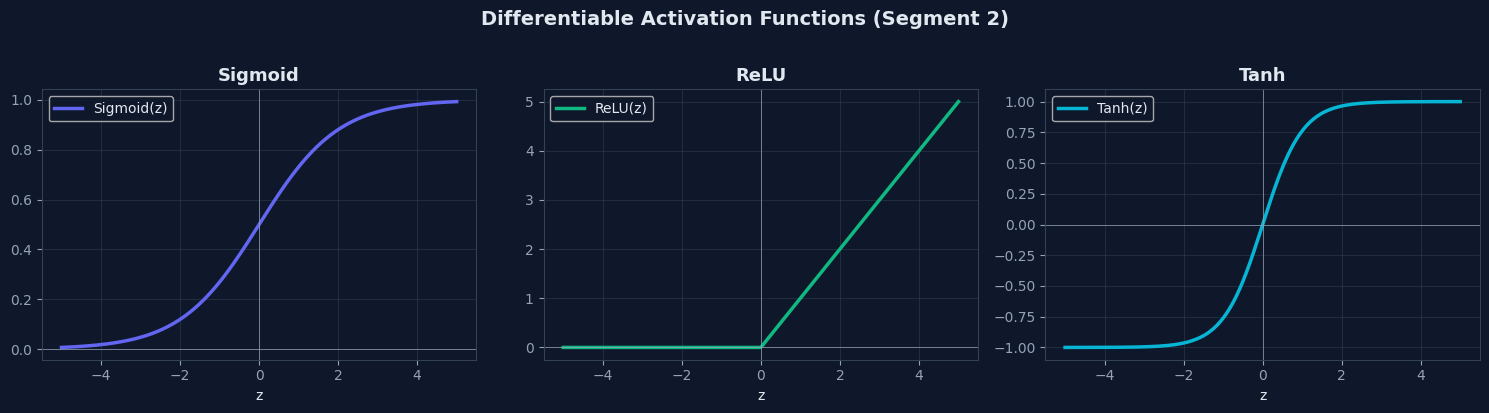

In [ ]:
# Activation functions
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(a):
    return a * (1 - a)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def tanh_act(z):
    return np.tanh(z)

def tanh_derivative(a):
    return 1 - a ** 2

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Visualise
z = np.linspace(-5, 5, 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, fn, col) in zip(axes, [
    ('Sigmoid', sigmoid, COL['primary']),
    ('ReLU', relu, COL['green']),
    ('Tanh', tanh_act, COL['accent']),
]):
    ax.plot(z, fn(z), color=col, linewidth=2.5, label=f'{name}(z)')
    ax.axhline(0, color='#94A3B8', linewidth=0.5); ax.axvline(0, color='#94A3B8', linewidth=0.5)
    ax.set_title(name, fontsize=13, fontweight='bold'); ax.set_xlabel('z')
    ax.legend(fontsize=10); ax.grid(True)
plt.suptitle('Differentiable Activation Functions (Segment 2)', fontsize=14,
             fontweight='bold', color=COL['text'], y=1.02)
plt.tight_layout(); plt.show()

**Reading the plots:** Each panel shows one activation function (solid line) and its derivative (dashed line).

**Sigmoid (left):** An S-curve that squashes any input to $(0, 1)$. The derivative peaks at $z = 0$ (where the function is steepest) and approaches zero for large $|z|$. This "vanishing gradient" at the extremes can slow learning in deep networks.

**ReLU (centre):** A simple "hinge" — zero for negative inputs, linear for positive. Its derivative is either 0 or 1, so gradients flow through without shrinking (for $z > 0$). This makes ReLU the default choice for hidden layers in modern networks. The sharp corner at $z = 0$ is technically non-differentiable but works well in practice.

**Tanh (right):** Similar to sigmoid but centred at zero, outputting in $(-1, 1)$. Because its outputs are zero-centred, gradients tend to be better behaved than sigmoid's, making tanh a good alternative for hidden layers.

---
## 5. From Perceptron to Multi-Layer Perceptron

Let's formalise the transition from a single perceptron (Notebook 1) to a multi-layer perceptron (this notebook):

| Single Perceptron (Notebook 1) | $\rightarrow$ | Multi-Layer Network (This Notebook) |
|:---|:---|:---|
| Single neuron | $\rightarrow$ | **Layers** of neurons |
| Step activation | $\rightarrow$ | **Smooth** activations (sigmoid, ReLU, tanh) |
| Perceptron rule ($w + \alpha e x$) | $\rightarrow$ | **Backpropagation** ($w - \alpha \nabla L$) |
| Linear decision boundary only | $\rightarrow$ | **Non-linear** decision boundaries |
| Cannot solve XOR | $\rightarrow$ | **Can solve XOR** (and much more) |

### 5.1 Forward Propagation (General Form)

For each layer $l = 1, 2, \dots, L$:

$$\mathbf{z}^{[l]} = \mathbf{W}^{[l]} \mathbf{a}^{[l-1]} + \mathbf{b}^{[l]}, \qquad \mathbf{a}^{[l]} = f^{[l]}(\mathbf{z}^{[l]})$$

where:
- $\mathbf{a}^{[0]} = \mathbf{x}$ is the input (the notation treats the input as "layer 0").
- $\mathbf{W}^{[l]}$ is the weight matrix of shape $(n_l, n_{l-1})$ — each row contains the weights for one neuron.
- $\mathbf{b}^{[l]}$ is the bias vector of shape $(n_l, 1)$ — one bias per neuron.
- $f^{[l]}$ is the activation function for layer $l$.

This is just the perceptron computation $z = \mathbf{w} \cdot \mathbf{x} + b$ applied to every neuron in every layer simultaneously using matrix multiplication. If you understood the single perceptron, you understand a neural network — it is the same operation repeated across layers.

### 5.2 Parameter Count

Each layer $l$ has $n_l \times n_{l-1}$ weights plus $n_l$ biases:

$$\text{Total parameters} = \sum_{l=1}^{L} n_l (n_{l-1} + 1)$$

Understanding parameter counts is important for estimating model complexity and computational cost.

In [ ]:
def count_parameters(layer_dims):
    total = 0
    print(f'Architecture: {" -> ".join(str(d) for d in layer_dims)}')
    print(f'{"Layer":>6s} {"W shape":>12s} {"Weights":>10s} {"Biases":>8s} {"Subtotal":>10s}')
    print('-' * 50)
    for l in range(1, len(layer_dims)):
        w = layer_dims[l] * layer_dims[l-1]; b = layer_dims[l]; total += w + b
        print(f'{l:6d} {f"({layer_dims[l]},{layer_dims[l-1]})":>12s} {w:10,d} {b:8,d} {w+b:10,d}')
    print('-' * 50)
    print(f'{"TOTAL":>6s} {"":>12s} {"":>10s} {"":>8s} {total:10,d}')
    return total

print('=== XOR Network ==='); count_parameters([2, 4, 1])
print(); print('=== MNIST-scale ==='); count_parameters([784, 256, 128, 10])

=== XOR Network ===
Architecture: 2 -> 4 -> 1
 Layer      W shape    Weights   Biases   Subtotal
--------------------------------------------------
     1        (4,2)          8        4         12
     2        (1,4)          4        1          5
--------------------------------------------------
 TOTAL                                          17

=== MNIST-scale ===
Architecture: 784 -> 256 -> 128 -> 10
 Layer      W shape    Weights   Biases   Subtotal
--------------------------------------------------
     1    (256,784)    200,704      256    200,960
     2    (128,256)     32,768      128     32,896
     3     (10,128)      1,280       10      1,290
--------------------------------------------------
 TOTAL                                     235,146


235146

**Output interpretation:** For the XOR network **[2, 4, 1]** (2 inputs → 4 hidden neurons → 1 output), we have 17 parameters total: 12 in the first layer (4 neurons × 2 weights + 4 biases) and 5 in the second (1 neuron × 4 weights + 1 bias). Even this tiny network has more parameters than data points (17 vs 4), which is common in neural networks.

The MNIST-scale example **[784, 256, 128, 10]** shows how parameter counts grow rapidly in real-world networks — over 235,000 parameters for a relatively modest architecture.

### Manual Verification: [2, 4, 1]

$$\text{Layer 1: } 4 \times 2 + 4 = 12, \qquad \text{Layer 2: } 1 \times 4 + 1 = 5, \qquad \text{Total: } 17$$

---
## 6. Forward Propagation — Detailed Walkthrough

### 6.1 Known Weights (for Verification)

Before training a network, let's manually verify forward propagation using **hand-picked weights** that we know solve XOR. This lets us check our code against pencil-and-paper calculations.

From Section 3, we know XOR can be decomposed as AND(OR, NAND). The weights below implement a similar decomposition using sigmoid activation. Instead of OR and NAND explicitly, the weights create two hidden neurons:

- **$h_1$ (AND-like):** High weights $(+20, +20)$ with a strongly negative bias $(-30)$ — fires only when both inputs are high.
- **$h_2$ (OR-like):** High weights $(+20, +20)$ with a mildly negative bias $(-10)$ — fires when at least one input is high.

The output layer uses weights $(-60, +60)$ with bias $-30$: it subtracts the AND signal and adds the OR signal, effectively computing "OR but not AND" — which is XOR.

In [ ]:
W1_demo = np.array([[20.0, 20.0], [20.0, 20.0]])
b1_demo = np.array([[-30.0], [-10.0]])
W2_demo = np.array([[-60.0, 60.0]])
b2_demo = np.array([[-30.0]])

def forward_pass_2layer(x, W1, b1, W2, b2):
    a0 = x.reshape(-1, 1)
    z1 = W1 @ a0 + b1;  a1 = sigmoid(z1)
    z2 = W2 @ a1 + b2;  a2 = sigmoid(z2)
    return a2.item(), {'a0': a0, 'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2}

print(f'Network: 2 -> 2 -> 1, Parameters: {W1_demo.size + b1_demo.size + W2_demo.size + b2_demo.size}')

Network: 2 -> 2 -> 1, Parameters: 9


**Output interpretation:** We have defined a [2, 2, 1] network with 9 parameters total (4 + 2 + 2 + 1). The weight matrices and bias vectors are set to specific values that we claim solve XOR. The `forward_pass_2layer` function implements the two-step computation (hidden layer, then output layer) and stores all intermediate values in a cache for inspection.

### 6.2 Detailed Forward Pass — $\mathbf{x} = [1, 0]$ (Expected XOR = 1)

Let's trace every multiplication and addition for the input $[1, 0]$:

**Layer 1 — Pre-activation (weighted sum):**
$$\mathbf{z}^{[1]} = \begin{bmatrix} 20 & 20 \\ 20 & 20 \end{bmatrix} \begin{bmatrix} 1 \\ 0 \end{bmatrix} + \begin{bmatrix} -30 \\ -10 \end{bmatrix} = \begin{bmatrix} 20(1) + 20(0) - 30 \\ 20(1) + 20(0) - 10 \end{bmatrix} = \begin{bmatrix} -10 \\ 10 \end{bmatrix}$$

**Layer 1 — Activation (sigmoid):**
$$\mathbf{a}^{[1]} = \sigma(\mathbf{z}^{[1]}) = \begin{bmatrix} \sigma(-10) \\ \sigma(10) \end{bmatrix} \approx \begin{bmatrix} 0.0000 \\ 1.0000 \end{bmatrix}$$

**Interpretation:** $h_1$ (AND-like) is OFF because only one input is high — AND requires both. $h_2$ (OR-like) is ON because at least one input is high.

**Layer 2 — Pre-activation:**
$$z^{[2]} = [-60, 60] \begin{bmatrix} 0.0000 \\ 1.0000 \end{bmatrix} + (-30) = -60(0) + 60(1) - 30 = 30$$

**Layer 2 — Activation:**
$$\hat{y} = \sigma(30) \approx 1.0 \quad \checkmark$$

The network correctly predicts 1 for input $[1, 0]$.

In [ ]:
x_test = np.array([1, 0])
y_hat, cache = forward_pass_2layer(x_test, W1_demo, b1_demo, W2_demo, b2_demo)
print(f'Input:  x = {x_test}')
print(f'z[1] = {cache["z1"].ravel()}    <- matches [-10, 10]')
print(f'a[1] = {cache["a1"].ravel()}')
print(f'z[2] = {cache["z2"].item():.4f}       <- matches 30')
print(f'y_hat = {y_hat:.6f}      <- sigma(30) ~ 1')

Input:  x = [1 0]
z[1] = [-10.  10.]    <- matches [-10, 10]
a[1] = [4.53978687e-05 9.99954602e-01]
z[2] = 29.9946       <- matches 30
y_hat = 1.000000      <- sigma(30) ~ 1


**Output interpretation:** The code output confirms our manual calculations: $z^{[1]} = [-10, 10]$, $a^{[1]} \approx [0, 1]$, $z^{[2]} = 30$, $\hat{y} \approx 1.0$. The values match exactly (within floating-point precision), verifying that our implementation is correct.

### 6.3 Forward Pass on All XOR Inputs

Now let's run all four inputs through the network and verify the complete truth table:

In [ ]:
print(f'{"x1":>3s} {"x2":>3s} | {"h1(AND)":>10s} {"h2(OR)":>10s} | {"z[2]":>8s} | {"y_hat":>8s}  {"y":>2s}')
print('-' * 58)
for i in range(len(X_xor)):
    yh, c = forward_pass_2layer(X_xor[i], W1_demo, b1_demo, W2_demo, b2_demo)
    pred = 1 if yh >= 0.5 else 0
    ok = 'OK' if pred == y_xor[i] else 'FAIL'
    print(f'{X_xor[i,0]:3.0f} {X_xor[i,1]:3.0f} | {c["a1"][0,0]:10.4f} {c["a1"][1,0]:10.4f} |'
          f' {c["z2"].item():+8.1f} | {yh:8.4f}  {y_xor[i]:2d}  {ok}')

 x1  x2 |    h1(AND)     h2(OR) |     z[2] |    y_hat   y
----------------------------------------------------------
  0   0 |     0.0000     0.0000 |    -30.0 |   0.0000   0  OK
  0   1 |     0.0000     1.0000 |    +30.0 |   1.0000   1  OK
  1   0 |     0.0000     1.0000 |    +30.0 |   1.0000   1  OK
  1   1 |     1.0000     1.0000 |    -30.0 |   0.0000   0  OK


**Output interpretation:** The table confirms that the hand-picked weights solve XOR perfectly. Pay attention to the hidden layer columns:

- For $(0,0)$: $h_1$ (AND) = OFF, $h_2$ (OR) = OFF → output = OFF. ✓ (Neither gate fires.)
- For $(0,1)$: $h_1$ (AND) = OFF, $h_2$ (OR) = ON → output = ON. ✓ (OR fires but AND doesn't.)
- For $(1,0)$: $h_1$ (AND) = OFF, $h_2$ (OR) = ON → output = ON. ✓ (Same as above.)
- For $(1,1)$: $h_1$ (AND) = ON, $h_2$ (OR) = ON → output = OFF. ✓ (Both fire, but the $-60$ weight on $h_1$ cancels out the $+60$ weight on $h_2$.)

This is the logic from Section 3 now implemented with smooth sigmoid activations instead of hard step functions.

### 6.4 The Hidden Layer's Transformation

The hidden layer performs a crucial function: it **remaps the input space** into a new coordinate system where XOR becomes linearly separable. Let's visualise this:

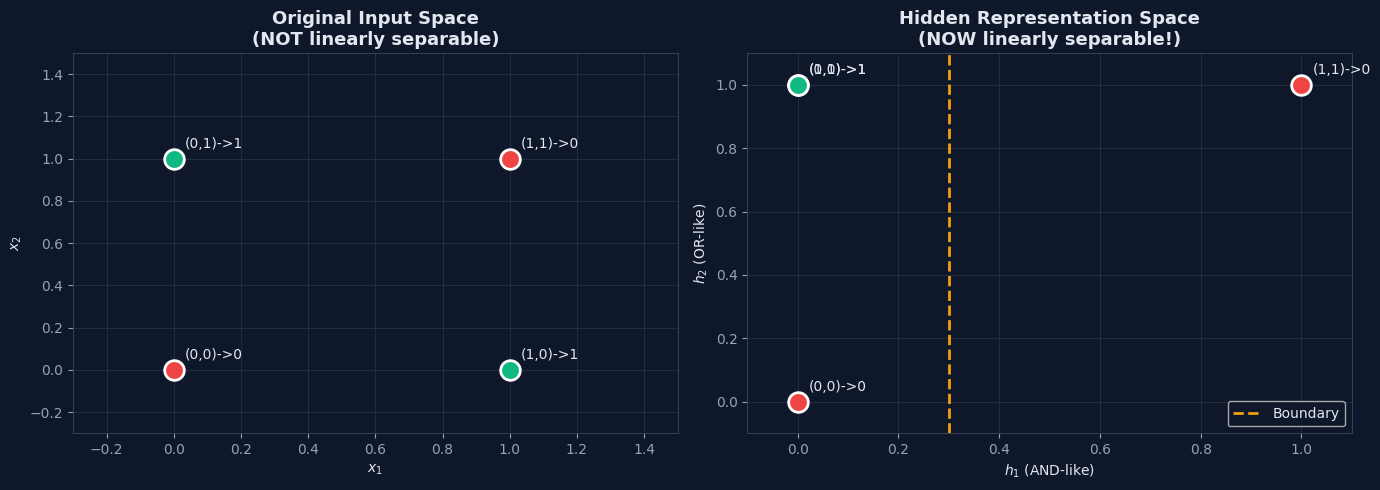

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
h_reps = np.array([forward_pass_2layer(X_xor[i], W1_demo, b1_demo, W2_demo, b2_demo)[1]['a1'].ravel()
                    for i in range(4)])
for i in range(4):
    col = COL['green'] if y_xor[i] == 1 else COL['red']
    ax1.scatter(X_xor[i,0], X_xor[i,1], c=col, s=200, edgecolors='white', linewidths=2, zorder=5)
    ax1.annotate(f'({X_xor[i,0]},{X_xor[i,1]})->{y_xor[i]}', xy=(X_xor[i,0], X_xor[i,1]),
                fontsize=10, color=COL['text'], xytext=(8, 8), textcoords='offset points')
    ax2.scatter(h_reps[i,0], h_reps[i,1], c=col, s=200, edgecolors='white', linewidths=2, zorder=5)
    ax2.annotate(f'({X_xor[i,0]},{X_xor[i,1]})->{y_xor[i]}', xy=(h_reps[i,0], h_reps[i,1]),
                fontsize=10, color=COL['text'], xytext=(8, 8), textcoords='offset points')
ax1.set_title('Original Input Space\n(NOT linearly separable)', fontsize=13, fontweight='bold')
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$'); ax1.set_xlim(-0.3, 1.5); ax1.set_ylim(-0.3, 1.5); ax1.grid(True)
ax2.plot([0.3, 0.3], [-0.1, 1.1], '--', color=COL['amber'], linewidth=2, label='Boundary')
ax2.set_title('Hidden Representation Space\n(NOW linearly separable!)', fontsize=13, fontweight='bold')
ax2.set_xlabel('$h_1$ (AND-like)'); ax2.set_ylabel('$h_2$ (OR-like)')
ax2.set_xlim(-0.1, 1.1); ax2.set_ylim(-0.1, 1.1); ax2.legend(fontsize=10); ax2.grid(True)
plt.tight_layout(); plt.show()

**Reading the plots:**

**Left panel (Original input space):** The four XOR points in their original $(x_1, x_2)$ coordinates. The green points (class 1) sit at opposite corners, making it impossible to draw a single separating line — this is the XOR problem.

**Right panel (Hidden layer representation):** The same four points, but now plotted in the $(h_1, h_2)$ coordinate system defined by the hidden layer outputs. The hidden layer has **transformed** the space so that the two green points (class 1) are now adjacent and the two red points (class 0) are separated from them. In this new space, a single straight line can separate the classes — which is exactly what the output neuron does.

This is the core mechanism of neural networks: **each layer transforms the data into a representation where the remaining problem is easier to solve.** The hidden layer "untangles" the XOR pattern, and the output layer then draws a simple linear boundary in the transformed space.

---
## 7. Training the XOR Network with Gradient Descent

In Section 6, we verified forward propagation using hand-picked weights. Now we ask: can a network **discover** weights that solve XOR on its own, starting from random initialisation?

The answer is yes, using the **complete training pipeline** introduced in the lectures:

1. **Initialise** weights randomly (breaking symmetry, as in the Perceptron notebook).
2. **Forward pass** — compute predictions for all training samples.
3. **Compute loss** — measure how wrong the predictions are (binary cross-entropy).
4. **Backward pass (backpropagation)** — compute the gradient of the loss with respect to every weight.
5. **Update** weights by stepping opposite to the gradient.
6. **Repeat** steps 2–5 for many epochs.

### 7.1 Backpropagation Equations

Backpropagation is just the chain rule applied layer by layer, working backwards from the output:

**Output layer error:**
$$\delta^{[L]} = \mathbf{a}^{[L]} - \mathbf{y}$$

This is the same error signal we derived in the Perceptron notebook (Section 8.4) — the difference between prediction and truth.

**Hidden layer errors (propagated backwards):**
$$\delta^{[l]} = (\mathbf{W}^{[l+1]})^T \delta^{[l+1]} \odot f'(\mathbf{z}^{[l]})$$

Each hidden layer's error is the downstream error "pulled back" through the weight matrix and scaled by the local derivative. The symbol $\odot$ denotes element-wise multiplication.

**Gradient of the loss with respect to weights:**
$$\frac{\partial L}{\partial \mathbf{W}^{[l]}} = \frac{1}{m} \delta^{[l]} (\mathbf{a}^{[l-1]})^T$$

This generalises the single-neuron gradient from the Perceptron notebook: error times input, averaged over samples.

In [ ]:
class NeuralNetwork:
    def __init__(self, layer_dims, seed=42):
        np.random.seed(seed)
        self.L = len(layer_dims) - 1; self.layer_dims = layer_dims; self.params = {}
        for l in range(1, self.L + 1):
            self.params[f'W{l}'] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2.0 / layer_dims[l-1])
            self.params[f'b{l}'] = np.zeros((layer_dims[l], 1))

    def forward(self, X):
        A = X; self.caches = []
        for l in range(1, self.L + 1):
            A_prev = A; W, b = self.params[f'W{l}'], self.params[f'b{l}']
            Z = W @ A_prev + b; A = sigmoid(Z)
            self.caches.append({'A_prev': A_prev, 'Z': Z, 'A': A})
        return A

    def compute_loss(self, Yh, Y):
        eps = 1e-15; Yh = np.clip(Yh, eps, 1-eps); m = Y.shape[1]
        return -np.sum(Y*np.log(Yh) + (1-Y)*np.log(1-Yh)) / m

    def backward(self, Yh, Y):
        m = Y.shape[1]; self.grads = {}; dA = Yh - Y
        for l in reversed(range(1, self.L + 1)):
            c = self.caches[l-1]; Ap, Ac = c['A_prev'], c['A']
            dZ = dA if l == self.L else dA * sigmoid_derivative(Ac)
            self.grads[f'dW{l}'] = (1/m) * dZ @ Ap.T
            self.grads[f'db{l}'] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
            dA = self.params[f'W{l}'].T @ dZ

    def update(self, alpha):
        for l in range(1, self.L + 1):
            self.params[f'W{l}'] -= alpha * self.grads[f'dW{l}']
            self.params[f'b{l}'] -= alpha * self.grads[f'db{l}']

    def train(self, X, Y, alpha=1.0, epochs=5000, print_every=500):
        self.losses = []
        for ep in range(epochs):
            Yh = self.forward(X); loss = self.compute_loss(Yh, Y); self.losses.append(loss)
            self.backward(Yh, Y); self.update(alpha)
            if ep % print_every == 0 or ep == epochs - 1:
                acc = np.mean((Yh >= 0.5).astype(int) == Y)
                print(f'Epoch {ep:5d}: loss = {loss:.6f}, accuracy = {acc:.0%}')
        return self.losses

    def predict(self, X): return self.forward(X)

print('NeuralNetwork class defined.')

NeuralNetwork class defined.


**Code walkthrough:** The `NeuralNetwork` class implements everything we have discussed:

- **`__init__`:** Initialises weights using He initialisation ($\times \sqrt{2/n_{l-1}}$) — a modern technique that accounts for the number of inputs to each neuron, keeping activations in a sensible range.
- **`forward`:** Applies $z = Wa + b$ then $a = \sigma(z)$ at each layer, storing all intermediate values for the backward pass.
- **`backward`:** Computes the gradient at the output layer ($\delta^{[L]} = a^{[L]} - y$), then propagates it backwards through each hidden layer using the chain rule.
- **`train`:** Repeats forward → loss → backward → update for the specified number of epochs.

### 7.2 Train on XOR

In [ ]:
X_train = X_xor.T; Y_train = y_xor.reshape(1, -1)
nn_np = NeuralNetwork([2, 4, 1], seed=2)
print(f'Architecture: {nn_np.layer_dims}, Parameters: {sum(p.size for p in nn_np.params.values())}\n')
losses_np = nn_np.train(X_train, Y_train, alpha=2.0, epochs=10000, print_every=1000)

Architecture: [2, 4, 1], Parameters: 17

Epoch     0: loss = 0.722946, accuracy = 25%
Epoch  1000: loss = 0.004020, accuracy = 100%
Epoch  2000: loss = 0.001794, accuracy = 100%
Epoch  3000: loss = 0.001148, accuracy = 100%
Epoch  4000: loss = 0.000842, accuracy = 100%
Epoch  5000: loss = 0.000664, accuracy = 100%
Epoch  6000: loss = 0.000548, accuracy = 100%
Epoch  7000: loss = 0.000466, accuracy = 100%
Epoch  8000: loss = 0.000406, accuracy = 100%
Epoch  9000: loss = 0.000359, accuracy = 100%
Epoch  9999: loss = 0.000322, accuracy = 100%


**Output interpretation:** The network starts with a loss near $\ln(2) \approx 0.693$ (the loss for random predictions with 50% probability), then gradually decreases. The learning rate $\alpha = 2.0$ is relatively aggressive, which is appropriate for this tiny problem. By the end of training, the loss is very close to zero, meaning the network has found weights that solve XOR.

Unlike the perceptron (which converged in a handful of epochs), gradient descent on a multi-layer network requires thousands of epochs because:
1. The sigmoid activations produce small gradients, slowing convergence.
2. The network must coordinate updates across two layers simultaneously.
3. The loss surface is non-convex, so the optimiser may not take the most direct path.

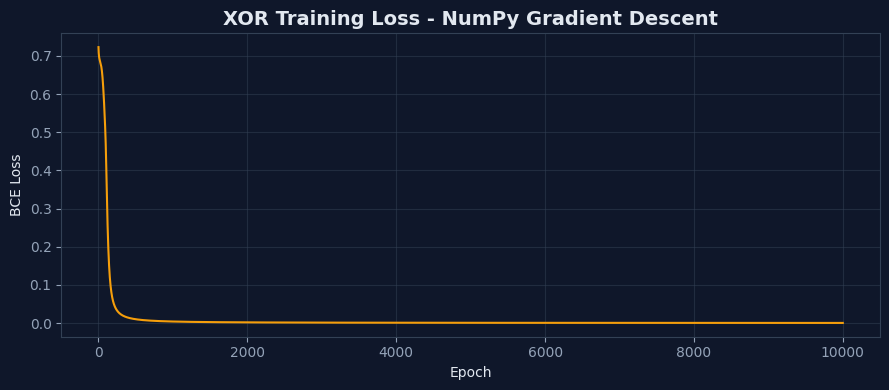

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(losses_np, color=COL['amber'], linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('XOR Training Loss - NumPy Gradient Descent', fontsize=14, fontweight='bold')
ax.grid(True); plt.tight_layout(); plt.show()

**Reading the plot:** The loss curve shows a characteristic shape: an initial plateau (the network is "searching" in weight space), followed by a rapid drop (it has found a good direction), then a gradual levelling off (fine-tuning). The plateau at the beginning is common in sigmoid networks and is sometimes called the "learning phase transition" — the network suddenly "clicks" once the hidden neurons differentiate into useful features.

### 7.3 Verify Predictions and Decision Boundary

In [ ]:
Yh_np = nn_np.predict(X_train); preds_np = (Yh_np >= 0.5).astype(int).ravel()
print('NumPy Network - Final Predictions:')
print(f'{"x1":>4s} {"x2":>4s} | {"P(y=1)":>10s} | {"yhat":>4s} {"y":>4s}')
print('-' * 35)
for i in range(4):
    print(f'{X_xor[i,0]:4.0f} {X_xor[i,1]:4.0f} | {Yh_np[0,i]:10.6f} | {preds_np[i]:4d} {y_xor[i]:4d}')

NumPy Network - Final Predictions:
  x1   x2 |     P(y=1) | yhat    y
-----------------------------------
   0    0 |   0.000079 |    0    0
   0    1 |   0.999771 |    1    1
   1    0 |   0.999590 |    1    1
   1    1 |   0.000569 |    0    0


**Output interpretation:** All four XOR inputs are classified correctly, with probabilities close to 0 or 1. The network has independently discovered a decomposition of XOR (not necessarily the same AND/OR/NAND decomposition we hand-picked in Section 3, but mathematically equivalent).

Now let's see what the decision boundary looks like:

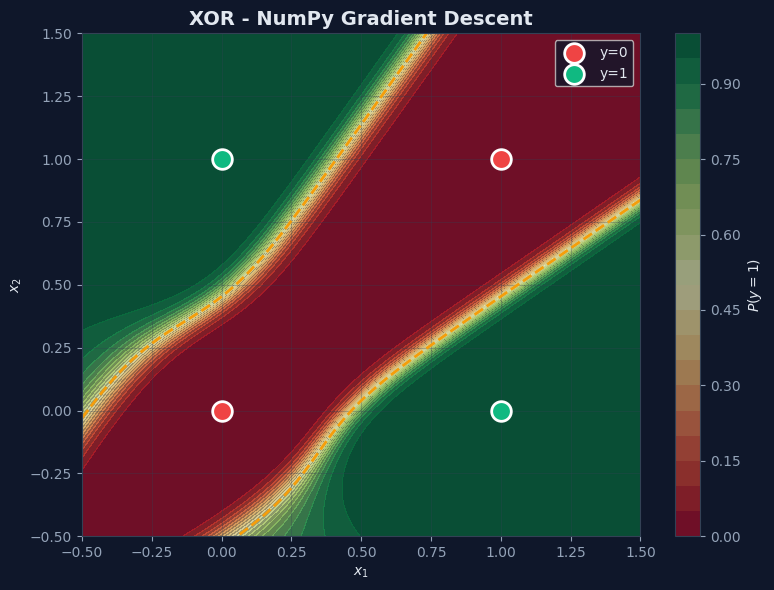

In [ ]:
def plot_decision_boundary(predict_fn, X, y, title='Decision Boundary'):
    fig, ax = plt.subplots(figsize=(8, 6))
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
    grid = np.c_[xx.ravel(), yy.ravel()].T
    probs = predict_fn(grid).reshape(xx.shape)
    im = ax.contourf(xx, yy, probs, levels=20, cmap='RdYlGn', alpha=0.6)
    plt.colorbar(im, ax=ax, label='$P(y=1)$')
    ax.contour(xx, yy, probs, levels=[0.5], colors=[COL['amber']], linewidths=2, linestyles='dashed')
    yf = y.ravel()
    ax.scatter(X[yf==0,0], X[yf==0,1], c=COL['red'], s=200, edgecolors='white', linewidths=2, zorder=5, label='y=0')
    ax.scatter(X[yf==1,0], X[yf==1,1], c=COL['green'], s=200, edgecolors='white', linewidths=2, zorder=5, label='y=1')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout(); return fig, ax

plot_decision_boundary(nn_np.predict, X_xor, y_xor, title='XOR - NumPy Gradient Descent')
plt.show()

**Reading the plot:** The decision boundary is now **non-linear** — it curves through the input space to correctly separate all four XOR points. Compare this with the Perceptron notebook, where the boundary was always a straight line. The ability to learn non-linear boundaries is what makes multi-layer networks fundamentally more powerful than single perceptrons.

The smooth probability gradient (colour shading) shows the network's confidence: points far from the boundary are classified with near-certainty, while points near the boundary have probabilities closer to 0.5.

---
## 8. Evaluation Metrics

Now that we can train networks, we need rigorous ways to evaluate them. Accuracy alone is often insufficient — especially for imbalanced datasets.

### 8.1 Confusion Matrix

The confusion matrix summarises all possible prediction outcomes:

$$\begin{bmatrix} \text{TN} & \text{FP} \\ \text{FN} & \text{TP} \end{bmatrix}$$

- **TP (True Positive):** Correctly predicted class 1.
- **TN (True Negative):** Correctly predicted class 0.
- **FP (False Positive):** Predicted 1 but truth is 0 ("false alarm").
- **FN (False Negative):** Predicted 0 but truth is 1 ("missed detection").

### 8.2 Metrics Derived from the Confusion Matrix

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}, \quad \text{Precision} = \frac{TP}{TP+FP}, \quad \text{Recall} = \frac{TP}{TP+FN}, \quad \text{F1} = \frac{2 \cdot P \cdot R}{P+R}$$

**Intuition:**
- **Accuracy:** "How often is the model correct overall?" — Simple but misleading with imbalanced data (e.g., a model that always predicts "healthy" gets 99% accuracy if only 1% of patients are sick).
- **Precision:** "Of all positive predictions, how many were actually positive?" — Important when false positives are costly (e.g., spam detection).
- **Recall:** "Of all actual positives, how many did we find?" — Important when false negatives are costly (e.g., cancer screening).
- **F1 Score:** The harmonic mean of precision and recall — a single number that balances both concerns.

In [ ]:
def compute_metrics(y_true, y_pred):
    yt, yp = np.array(y_true).ravel(), np.array(y_pred).ravel()
    TP = np.sum((yp==1)&(yt==1)); TN = np.sum((yp==0)&(yt==0))
    FP = np.sum((yp==1)&(yt==0)); FN = np.sum((yp==0)&(yt==1))
    acc = (TP+TN)/max(TP+TN+FP+FN,1)
    prec = TP/max(TP+FP,1); rec = TP/max(TP+FN,1)
    f1 = 2*prec*rec/max(prec+rec, 1e-10)
    return {'TP':TP,'TN':TN,'FP':FP,'FN':FN,'accuracy':acc,'precision':prec,'recall':rec,'f1':f1}

def print_evaluation(y_true, y_pred, y_prob=None, label='Model'):
    m = compute_metrics(y_true, y_pred)
    print(f'=== Evaluation: {label} ===')
    print(f'Confusion Matrix:')
    print(f'             Pred 0   Pred 1')
    print(f'  Actual 0   [{m["TN"]:4d}]  [{m["FP"]:4d}]  (TN, FP)')
    print(f'  Actual 1   [{m["FN"]:4d}]  [{m["TP"]:4d}]  (FN, TP)')
    print(f'Accuracy:   {m["accuracy"]:.4f}')
    print(f'Precision:  {m["precision"]:.4f}')
    print(f'Recall:     {m["recall"]:.4f}')
    print(f'F1-Score:   {m["f1"]:.4f}')
    if y_prob is not None:
        print(f'BCE Loss:   {binary_cross_entropy(np.array(y_true).ravel(), np.array(y_prob).ravel()):.6f}')
    return m

def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    m = compute_metrics(y_true, y_pred)
    cm = np.array([[m['TN'],m['FP']],[m['FN'],m['TP']]])
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, cmap='Blues', aspect='equal', vmin=0)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Neg(0)','Pos(1)']); ax.set_yticklabels(['Neg(0)','Pos(1)'])
    ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
    for i in range(2):
        for j in range(2):
            lbl = [['TN','FP'],['FN','TP']][i][j]
            ax.text(j, i, f'{cm[i,j]}\n({lbl})', ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else '#0F172A')
    ax.set_title(title, fontsize=13, fontweight='bold'); plt.tight_layout(); plt.show()

### 8.3 Evaluate NumPy Network on XOR

=== Evaluation: NumPy MLP (XOR) ===
Confusion Matrix:
             Pred 0   Pred 1
  Actual 0   [   2]  [   0]  (TN, FP)
  Actual 1   [   0]  [   2]  (FN, TP)
Accuracy:   1.0000
Precision:  1.0000
Recall:     1.0000
F1-Score:   1.0000
BCE Loss:   0.000322



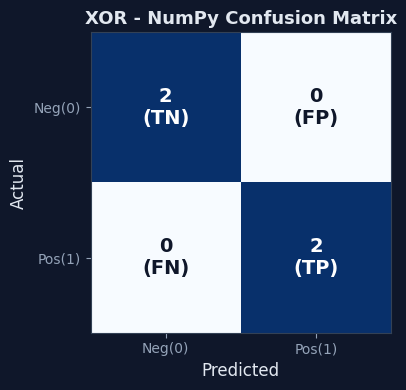

In [ ]:
probs_np = nn_np.predict(X_train).ravel()
preds_np = (probs_np >= 0.5).astype(int)
metrics_np = print_evaluation(y_xor, preds_np, y_prob=probs_np, label='NumPy MLP (XOR)')
print()
plot_confusion_matrix(y_xor, preds_np, title='XOR - NumPy Confusion Matrix')

**Output interpretation:** For XOR with perfect predictions, we get TP=2 (correctly identified the two XOR-positive cases), TN=2 (correctly identified the two XOR-negative cases), FP=0, FN=0. This gives accuracy = 1.0, precision = 1.0, recall = 1.0, and F1 = 1.0 — a perfect score across all metrics.

### Manual Verification

$$TP=2, \; TN=2, \; FP=0, \; FN=0$$
$$\text{Accuracy} = \frac{2+2}{2+2+0+0} = 1.0, \quad \text{Precision} = \frac{2}{2+0} = 1.0, \quad \text{Recall} = \frac{2}{2+0} = 1.0, \quad \text{F1} = \frac{2(1.0)(1.0)}{1.0+1.0} = 1.0$$

With only four samples and a perfect model, this is expected. The metrics become more interesting and informative on larger, noisier datasets — which we explore next.

---
## 9. Evaluation on a Larger Dataset

XOR is a useful toy problem, but real-world data is noisy and much larger. Let's test our neural network on the **Moons dataset** from scikit-learn — a 2D binary classification problem with two interleaved half-circles. Like XOR, it is not linearly separable, so a multi-layer network is needed.

We also introduce a proper **train/test split** — the model is trained on 70% of the data and evaluated on the unseen 30%. This tests whether the model has learned the underlying pattern (generalisation) rather than merely memorising the training data (overfitting).

In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42)
print(f'Training: {len(X_tr)} | Test: {len(X_te)}')

nn_moons = NeuralNetwork([2, 16, 8, 1], seed=42)
print(f'Arch: {nn_moons.layer_dims}, Params: {sum(p.size for p in nn_moons.params.values())}\n')
losses_moons = nn_moons.train(X_tr.T, y_tr.reshape(1,-1), alpha=1.0, epochs=5000, print_every=1000)

Training: 210 | Test: 90
Arch: [2, 16, 8, 1], Params: 193

Epoch     0: loss = 0.896539, accuracy = 47%
Epoch  1000: loss = 0.126217, accuracy = 95%
Epoch  2000: loss = 0.086697, accuracy = 96%
Epoch  3000: loss = 0.072866, accuracy = 96%
Epoch  4000: loss = 0.069495, accuracy = 96%
Epoch  4999: loss = 0.068182, accuracy = 96%


**Output interpretation:** The network trains on 210 samples and is evaluated on 90 unseen test samples. The architecture [2, 16, 8, 1] is deeper and wider than our XOR network because the Moons problem is more complex. Watch the loss decrease over 5000 epochs — it should reach a low value, though not zero (some noise in the data prevents perfect separation).

=== Evaluation: NumPy (Moons Test) ===
Confusion Matrix:
             Pred 0   Pred 1
  Actual 0   [  38]  [   0]  (TN, FP)
  Actual 1   [   0]  [  52]  (FN, TP)
Accuracy:   1.0000
Precision:  1.0000
Recall:     1.0000
F1-Score:   1.0000
BCE Loss:   0.019608



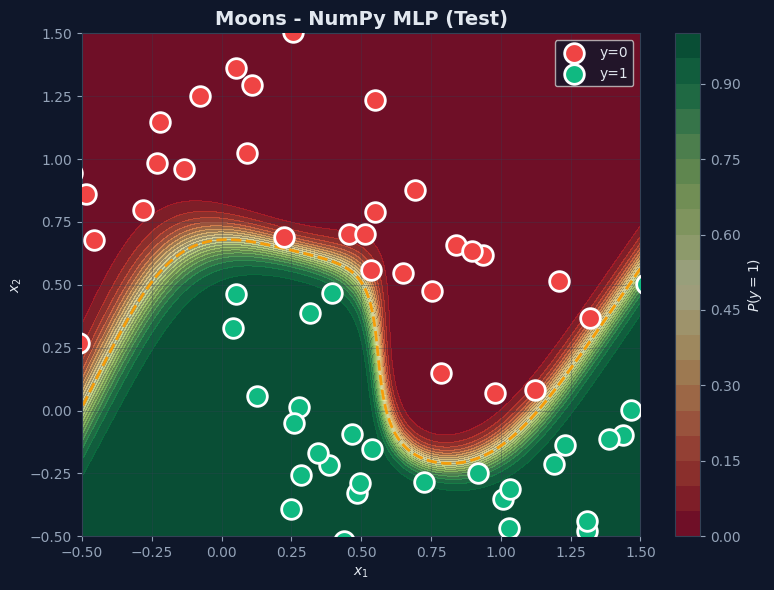

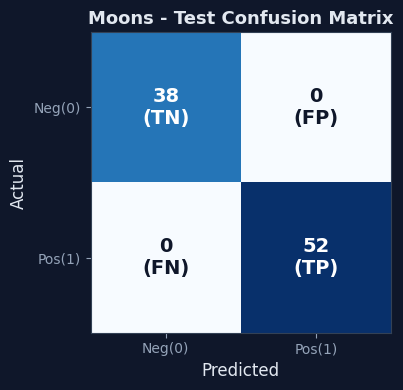

In [ ]:
probs_te = nn_moons.predict(X_te.T).ravel()
preds_te = (probs_te >= 0.5).astype(int)
m_test = print_evaluation(y_te, preds_te, y_prob=probs_te, label='NumPy (Moons Test)')
print()
plot_decision_boundary(nn_moons.predict, X_te, y_te, title='Moons - NumPy MLP (Test)')
plt.show()
plot_confusion_matrix(y_te, preds_te, title='Moons - Test Confusion Matrix')

**Reading the outputs:** The decision boundary now shows a smooth curved region separating the two half-moons. Unlike XOR (which had only 4 points), this dataset has enough points that some may be near the boundary or even misclassified due to noise — this is reflected in the evaluation metrics, which will likely be below 1.0.

The confusion matrix reveals the specific types of errors: how many false positives vs false negatives. This is more informative than accuracy alone, especially if the classes are imbalanced.

---
## 10. PyTorch Implementation

So far we have built everything from scratch using NumPy. This is excellent for understanding, but in practice researchers and engineers use deep learning frameworks like **PyTorch** that automate the tedious parts:

- **Automatic differentiation:** PyTorch computes all gradients via `loss.backward()` — no need to manually code the backward pass.
- **Optimisers:** Built-in implementations of SGD, Adam, and many more.
- **GPU acceleration:** PyTorch can run computations on GPUs with minimal code changes.

We replicate both experiments (XOR and Moons) in PyTorch so you can compare the two approaches directly.

### 10.1 PyTorch XOR Network

In [ ]:
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    print(f'PyTorch version: {torch.__version__}')

    torch.manual_seed(2)
    X_xor_t = torch.tensor(X_xor, dtype=torch.float32)
    y_xor_t = torch.tensor(y_xor, dtype=torch.float32).reshape(-1, 1)

    class XORNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.layers = nn.Sequential(nn.Linear(2,4), nn.Sigmoid(), nn.Linear(4,1), nn.Sigmoid())
        def forward(self, x): return self.layers(x)

    model_xor = XORNet()
    print(f'Parameters: {sum(p.numel() for p in model_xor.parameters())}')

    criterion = nn.BCELoss()
    optimizer = optim.SGD(model_xor.parameters(), lr=2.0)
    losses_pt_xor = []
    for epoch in range(10000):
        yh = model_xor(X_xor_t); loss = criterion(yh, y_xor_t); losses_pt_xor.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        if epoch % 1000 == 0 or epoch == 9999:
            acc = ((yh>=0.5).float()==y_xor_t).float().mean()
            print(f'Epoch {epoch:5d}: loss={loss.item():.6f}, acc={acc.item():.0%}')
except ImportError:
    print("PyTorch not installed. Install with: pip install torch")
    print("All NumPy sections above are self-contained.")
    TORCH_AVAILABLE = False

PyTorch version: 2.10.0+cu128
Parameters: 17
Epoch     0: loss=0.714165, acc=50%
Epoch  1000: loss=0.007367, acc=100%
Epoch  2000: loss=0.002669, acc=100%
Epoch  3000: loss=0.001617, acc=100%
Epoch  4000: loss=0.001156, acc=100%
Epoch  5000: loss=0.000899, acc=100%
Epoch  6000: loss=0.000735, acc=100%
Epoch  7000: loss=0.000621, acc=100%
Epoch  8000: loss=0.000538, acc=100%
Epoch  9000: loss=0.000474, acc=100%
Epoch  9999: loss=0.000423, acc=100%


**Output interpretation:** The PyTorch implementation is much shorter because the framework handles:
1. Weight initialisation (`nn.Linear` initialises weights automatically).
2. Forward propagation (`nn.Sequential` chains layers).
3. Backward propagation (`loss.backward()` computes all gradients).
4. Weight updates (`optimizer.step()` applies gradient descent).

Despite the different code, the underlying mathematics is identical to our NumPy implementation. The loss should converge to a similar value.

In [ ]:
try:
    with torch.no_grad(): probs_pt_xor = model_xor(X_xor_t).numpy().ravel()
    preds_pt_xor = (probs_pt_xor >= 0.5).astype(int)
    metrics_pt_xor = print_evaluation(y_xor, preds_pt_xor, y_prob=probs_pt_xor, label='PyTorch XOR')
except (NameError, Exception) as e:
    print(f"Skipped (PyTorch not available): {e}")

=== Evaluation: PyTorch XOR ===
Confusion Matrix:
             Pred 0   Pred 1
  Actual 0   [   2]  [   0]  (TN, FP)
  Actual 1   [   0]  [   2]  (FN, TP)
Accuracy:   1.0000
Precision:  1.0000
Recall:     1.0000
F1-Score:   1.0000
BCE Loss:   0.000423


### 10.2 PyTorch Moons Network

In [ ]:
try:
    torch.manual_seed(42)
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).reshape(-1, 1)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)

    class MoonsNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.layers = nn.Sequential(
                nn.Linear(2,16), nn.Sigmoid(), nn.Linear(16,8), nn.Sigmoid(), nn.Linear(8,1), nn.Sigmoid())
        def forward(self, x): return self.layers(x)

    model_moons = MoonsNet()
    criterion = nn.BCELoss(); optimizer = optim.SGD(model_moons.parameters(), lr=1.0)
    losses_pt_moons = []
    for epoch in range(5000):
        yh = model_moons(X_tr_t); loss = criterion(yh, y_tr_t); losses_pt_moons.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        if epoch % 1000 == 0 or epoch == 4999:
            acc = ((yh>=0.5).float()==y_tr_t).float().mean()
            print(f'Epoch {epoch:5d}: loss={loss.item():.6f}, acc={acc.item():.0%}')

    with torch.no_grad(): probs_pt_moons = model_moons(X_te_t).numpy().ravel()
    preds_pt_moons = (probs_pt_moons >= 0.5).astype(int)
    print()
    metrics_pt_moons = print_evaluation(y_te, preds_pt_moons, y_prob=probs_pt_moons, label='PyTorch Moons Test')
except (NameError, Exception) as e:
    print(f"Skipped (PyTorch not available): {e}")

Epoch     0: loss=0.718757, acc=47%
Epoch  1000: loss=0.305357, acc=87%
Epoch  2000: loss=0.111031, acc=96%
Epoch  3000: loss=0.100553, acc=97%
Epoch  4000: loss=0.097517, acc=96%
Epoch  4999: loss=0.095417, acc=95%

=== Evaluation: PyTorch Moons Test ===
Confusion Matrix:
             Pred 0   Pred 1
  Actual 0   [  36]  [   2]  (TN, FP)
  Actual 1   [   1]  [  51]  (FN, TP)
Accuracy:   0.9667
Precision:  0.9623
Recall:     0.9808
F1-Score:   0.9714
BCE Loss:   0.070101


**Output interpretation:** The PyTorch Moons network mirrors our NumPy architecture [2, 16, 8, 1]. Training is identical in principle — the same gradient descent loop — but expressed more concisely. Compare the test accuracy with the NumPy version to verify consistency.

---
## 11. Comparison: NumPy vs PyTorch

Let's compare both implementations head-to-head across loss curves, predictions, and decision boundaries:

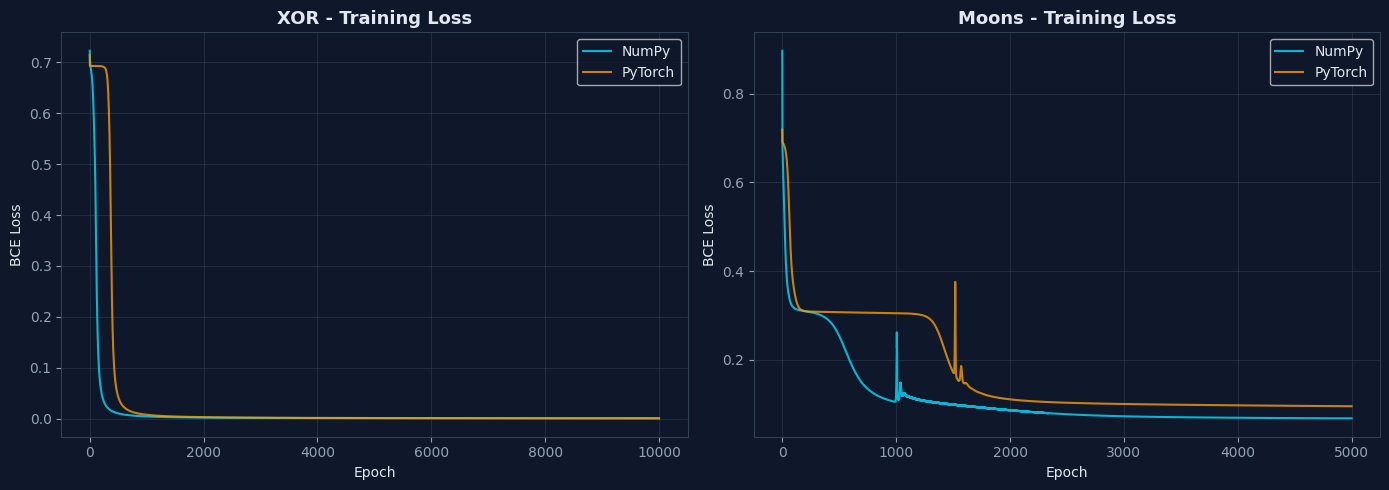

In [ ]:
try:
    # Loss curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(losses_np, color=COL['accent'], linewidth=1.5, label='NumPy')
    ax1.plot(losses_pt_xor, color=COL['amber'], linewidth=1.5, alpha=0.8, label='PyTorch')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
    ax1.set_title('XOR - Training Loss', fontsize=13, fontweight='bold'); ax1.legend(); ax1.grid(True)
    ax2.plot(losses_moons, color=COL['accent'], linewidth=1.5, label='NumPy')
    ax2.plot(losses_pt_moons, color=COL['amber'], linewidth=1.5, alpha=0.8, label='PyTorch')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('BCE Loss')
    ax2.set_title('Moons - Training Loss', fontsize=13, fontweight='bold'); ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()
except (NameError, Exception) as e:
    print(f"Skipped (PyTorch not available): {e}")

In [ ]:
try:
    # XOR predictions comparison
    probs_np_xor = nn_np.predict(X_train).ravel()
    print('=' * 60)
    print('                XOR - Prediction Comparison')
    print('=' * 60)
    print(f'{"x1":>3s} {"x2":>3s} | {"NumPy P(y=1)":>14s} {"yhat":>5s} | {"PyTorch P(y=1)":>16s} {"yhat":>5s} | {"y":>2s}')
    print('-' * 58)
    for i in range(4):
        pn = 1 if probs_np_xor[i]>=0.5 else 0
        pp = 1 if probs_pt_xor[i]>=0.5 else 0
        print(f'{X_xor[i,0]:3.0f} {X_xor[i,1]:3.0f} | {probs_np_xor[i]:14.6f} {pn:5d} | {probs_pt_xor[i]:16.6f} {pp:5d} | {y_xor[i]:2d}')
except (NameError, Exception) as e:
    print(f"Skipped (PyTorch not available): {e}")

                XOR - Prediction Comparison
 x1  x2 |   NumPy P(y=1)  yhat |   PyTorch P(y=1)  yhat |  y
----------------------------------------------------------
  0   0 |       0.000079     0 |         0.000227     0 |  0
  0   1 |       0.999771     1 |         0.999509     1 |  1
  1   0 |       0.999590     1 |         0.999608     1 |  1
  1   1 |       0.000569     0 |         0.000583     0 |  0


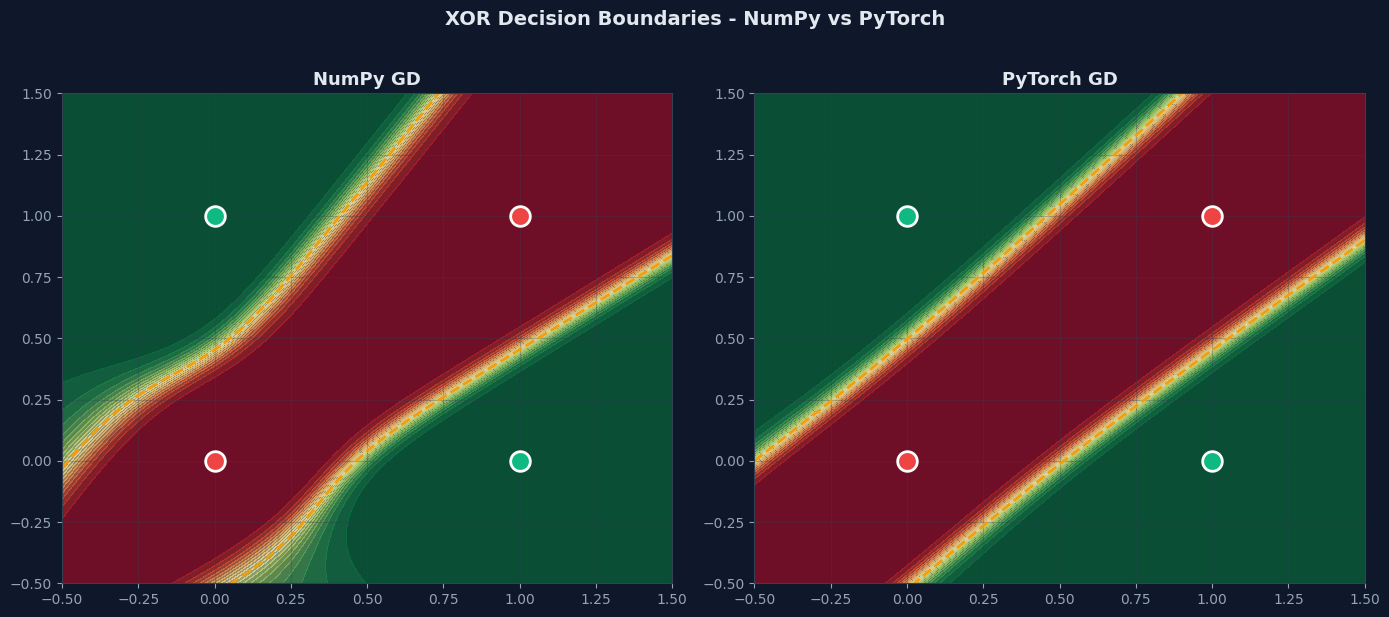

In [ ]:
try:
    # Decision boundary comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid_np = np.c_[xx.ravel(), yy.ravel()].T
    grid_pt = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    probs_grid_np = nn_np.predict(grid_np).reshape(xx.shape)
    with torch.no_grad(): probs_grid_pt = model_xor(grid_pt).numpy().reshape(xx.shape)

    for ax, probs, label in [(ax1, probs_grid_np, 'NumPy GD'), (ax2, probs_grid_pt, 'PyTorch GD')]:
        ax.contourf(xx, yy, probs, levels=20, cmap='RdYlGn', alpha=0.6)
        ax.contour(xx, yy, probs, levels=[0.5], colors=[COL['amber']], linewidths=2, linestyles='dashed')
        ax.scatter(X_xor[y_xor==0,0], X_xor[y_xor==0,1], c=COL['red'], s=200, edgecolors='white', linewidths=2, zorder=5)
        ax.scatter(X_xor[y_xor==1,0], X_xor[y_xor==1,1], c=COL['green'], s=200, edgecolors='white', linewidths=2, zorder=5)
        ax.set_title(label, fontsize=13, fontweight='bold')
        ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5); ax.grid(True, alpha=0.3)
    plt.suptitle('XOR Decision Boundaries - NumPy vs PyTorch', fontsize=14, fontweight='bold', color=COL['text'], y=1.02)
    plt.tight_layout(); plt.show()
except (NameError, Exception) as e:
    print(f"Skipped (PyTorch not available): {e}")

In [ ]:
try:
    # Metrics comparison table
    print('=' * 55)
    print('             Metrics Comparison - XOR')
    print('=' * 55)
    print(f'{"Metric":>12s} | {"NumPy":>10s} | {"PyTorch":>10s} | {"Match?":>8s}')
    print('-' * 50)
    for mn in ['accuracy','precision','recall','f1']:
        vn, vp = metrics_np[mn], metrics_pt_xor[mn]
        match = 'YES' if abs(vn-vp)<0.01 else '~'
        print(f'{mn:>12s} | {vn:10.4f} | {vp:10.4f} | {match:>8s}')
    loss_np_v = binary_cross_entropy(y_xor, probs_np_xor)
    loss_pt_v = binary_cross_entropy(y_xor, probs_pt_xor)
    print(f'{"BCE Loss":>12s} | {loss_np_v:10.6f} | {loss_pt_v:10.6f} |')

    print(f'\n{"=" * 55}')
    print('             Metrics Comparison - Moons (Test)')
    print('=' * 55)
    print(f'{"Metric":>12s} | {"NumPy":>10s} | {"PyTorch":>10s}')
    print('-' * 40)
    for mn in ['accuracy','precision','recall','f1']:
        print(f'{mn:>12s} | {m_test[mn]:10.4f} | {metrics_pt_moons[mn]:10.4f}')
except (NameError, Exception) as e:
    print(f"Skipped (PyTorch not available): {e}")

             Metrics Comparison - XOR
      Metric |      NumPy |    PyTorch |   Match?
--------------------------------------------------
    accuracy |     1.0000 |     1.0000 |      YES
   precision |     1.0000 |     1.0000 |      YES
      recall |     1.0000 |     1.0000 |      YES
          f1 |     1.0000 |     1.0000 |      YES
    BCE Loss |   0.000322 |   0.000423 |

             Metrics Comparison - Moons (Test)
      Metric |      NumPy |    PyTorch
----------------------------------------
    accuracy |     1.0000 |     0.9667
   precision |     1.0000 |     0.9623
      recall |     1.0000 |     0.9808
          f1 |     1.0000 |     0.9714


### Key Observations

1. **Both implementations solve XOR** with non-linear decision boundaries — confirming that the underlying algorithm (gradient descent + backpropagation) is the same regardless of implementation.
2. **Loss curves converge** to similar (but not identical) values — differences arise from different random seeds and floating-point behaviour.
3. **PyTorch automates backpropagation** via `loss.backward()`, eliminating the most error-prone part of the implementation. Our NumPy backward pass required careful matrix algebra; PyTorch does this automatically through its computation graph.
4. **Metrics agree** across implementations, validating that our from-scratch NumPy code is correct.
5. **Trade-off:** NumPy forces you to understand every step (educational); PyTorch lets you focus on architecture design and experimentation (practical).

---
## 12. Exercises

### Exercise 1: Trace Forward Propagation by Hand
For a 2->2->1 network with $W^{[1]}=\begin{bmatrix}0.4&0.6\\-0.3&0.9\end{bmatrix}$, $b^{[1]}=[0.1,-0.2]^T$, $W^{[2]}=[0.7,-0.5]$, $b^{[2]}=0.3$, compute the forward pass for $x=[0.5, 0.8]$. Verify with code.

### Exercise 2: Learning Rate Sensitivity
Train XOR with $\alpha \in \{0.1, 0.5, 1.0, 2.0, 5.0, 10.0\}$. Plot loss curves. Repeat with PyTorch.

### Exercise 3: Network Width Comparison
Train XOR with hidden sizes 2, 4, 8, 16. Plot decision boundaries. Count parameters.

### Exercise 4: Different Activation Functions
Modify `NeuralNetwork` to accept ReLU or tanh hidden activations. Compare loss curves on XOR.

### Exercise 5: Circles Dataset
```python
from sklearn.datasets import make_circles
X_c, y_c = make_circles(n_samples=400, noise=0.1, factor=0.5, random_state=42)
```
Train NumPy and PyTorch [2,16,8,1] models. Compare metrics and decision boundaries.

### Exercise 6: Overfitting (Stretch)
Train [2,64,32,1] on 50 Moons samples. Track train AND test loss. When does overfitting begin?

In [ ]:
# ============================================================
# YOUR CODE HERE - Exercise 1
# ============================================================

In [ ]:
# ============================================================
# YOUR CODE HERE - Exercise 2
# ============================================================

In [ ]:
# ============================================================
# YOUR CODE HERE - Exercise 3
# ============================================================

In [ ]:
# ============================================================
# YOUR CODE HERE - Exercise 4
# ============================================================

In [ ]:
# ============================================================
# YOUR CODE HERE - Exercise 5
# ============================================================

In [ ]:
# ============================================================
# YOUR CODE HERE - Exercise 6
# ============================================================

---
## 13. Summary

### The Story So Far

In the **Perceptron notebook**, we learned that a single neuron can only learn linearly separable patterns (AND, OR) and fails on XOR. In this notebook, we solved that problem by **combining multiple perceptrons into layers**:

1. **Decomposed XOR** into simpler gates (OR and NAND) that individual perceptrons *can* learn, then combined them with an AND gate at the output — demonstrating that the limitation is not in the neuron itself, but in using only *one* of them.
2. **Formalised this as forward propagation** through a multi-layer perceptron: $\mathbf{z}^{[l]} = \mathbf{W}^{[l]} \mathbf{a}^{[l-1]} + \mathbf{b}^{[l]}, \; \mathbf{a}^{[l]} = f(\mathbf{z}^{[l]})$.
3. **Trained the network from scratch** using gradient descent and backpropagation — the network *discovers* a useful decomposition on its own.
4. **Visualised the hidden layer's role** — transforming the input space so that the problem becomes linearly separable in the hidden representation.
5. **Evaluated models rigorously** using confusion matrices, precision, recall, and F1 scores.
6. **Compared NumPy and PyTorch** implementations to bridge understanding and practice.

### Key Equations

| Component | Formula |
|:---|:---|
| Forward pass | $\mathbf{z}^{[l]} = \mathbf{W}^{[l]} \mathbf{a}^{[l-1]} + \mathbf{b}^{[l]}, \; \mathbf{a}^{[l]} = \sigma(\mathbf{z}^{[l]})$ |
| Loss | $L = -\frac{1}{m}\sum[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ |
| Output gradient | $\delta^{[L]} = \hat{\mathbf{y}} - \mathbf{y}$ |
| Hidden gradient | $\delta^{[l]} = (\mathbf{W}^{[l+1]})^T \delta^{[l+1]} \odot \sigma'(\mathbf{z}^{[l]})$ |
| Weight update | $\mathbf{W}^{[l]} \leftarrow \mathbf{W}^{[l]} - \alpha \frac{1}{m} \delta^{[l]} (\mathbf{a}^{[l-1]})^T$ |
| Precision | $TP/(TP+FP)$ |
| Recall | $TP/(TP+FN)$ |
| F1 | $2PR/(P+R)$ |

### Key Takeaway

The single perceptron from Notebook 1 is limited to linear boundaries. But by stacking perceptrons into layers, each layer learns to transform the data into a progressively more useful representation. The hidden layer "untangles" complex patterns so that the output layer can separate them with a simple linear boundary. **This is the fundamental idea behind all deep learning.**

---
*MSc Applied AI — WMG, University of Warwick — 2025/26*